In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.3 MB/s eta 0:00:00


In [3]:
import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [4]:
BASE_DIR = '/content/drive/MyDrive/NLP_Final_Project_Final'

DATA_DIR              = f'{BASE_DIR}/data/splits'
CLASSICAL_MODEL_DIR   = f'{BASE_DIR}/models/classical'
CLASSICAL_ARTIFACT_DIR = f'{BASE_DIR}/artifacts/classical'

INDOBERT_ARTIFACT_DIR      = f'{BASE_DIR}/artifacts/indobert'
INDODISTILBERT_ARTIFACT_DIR = f'{BASE_DIR}/artifacts/indodistilbert'

FINAL_ARTIFACT_DIR = f'{BASE_DIR}/artifacts/final_evaluation'
os.makedirs(FINAL_ARTIFACT_DIR, exist_ok=True)

print("FINAL_ARTIFACT_DIR:", FINAL_ARTIFACT_DIR)

FINAL_ARTIFACT_DIR: /content/drive/MyDrive/NLP_Final_Project_Final/artifacts/final_evaluation


In [5]:
# LOAD DATA
df_test = pd.read_csv(f'{DATA_DIR}/test_data.csv')

print("Test shape:", df_test.shape)
display(df_test.head())

y_test      = df_test['label_id'].values
label_names = ['negatif', 'netral', 'positif']

Test shape: (975, 4)


,judul,text_clean,sentimen,label_id
0,"Gempa Magnitudo 7,7 Guncang Myanmar, Terasa Hi...","gempa magnitudo 7,7 guncang myanmar, terasa hi...",negatif,0
1,"IHSG Nyaris Sentuh 7.300-an, Digendong BBRI & ...","ihsg nyaris sentuh 7.300-an, digendong bbri & ...",positif,2
2,IHSG Gak Jadi Happy Weekend Tertekan Kinerja S...,ihsg gak jadi happy weekend tertekan kinerja s...,negatif,0
3,"Inflasi AS Lanjut Naik, Bitcoin Cs Kompak Meng...","inflasi as lanjut naik, bitcoin cs kompak meng...",positif,2
4,796 Ribu AgenBRILink Siap Layani Masyarakat Se...,796 ribu agenbrilink siap layani masyarakat se...,positif,2


In [6]:
def compute_metrics_full(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return {
        'accuracy'          : acc,
        'precision_macro'   : precision_macro,
        'recall_macro'      : recall_macro,
        'f1_macro'          : f1_macro,
        'precision_weighted': precision_weighted,
        'recall_weighted'   : recall_weighted,
        'f1_weighted'       : f1_weighted
    }

def plot_confusion_matrix(ax, cm, labels, title):
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title, fontsize=13, fontweight='bold')
    tick_marks = np.arange(len(labels))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(labels)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(labels)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

    threshold = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, str(cm[i, j]),
                ha='center', va='center',
                color='white' if cm[i, j] > threshold else 'black'
            )
    return im

In [7]:
# PREPROCESSING MODEL KLASIK
stop_factory     = StopWordRemoverFactory()
stopwords_default = set(stop_factory.get_stop_words())
keep_words        = {'tidak', 'bukan', 'belum', 'jangan', 'kurang'}
custom_stopwords  = stopwords_default - keep_words
stemmer           = StemmerFactory().create_stemmer()

def remove_stopwords_custom(text):
    tokens = str(text).split()
    tokens = [tok for tok in tokens if tok not in custom_stopwords]
    return ' '.join(tokens)

def preprocess_classical(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = remove_stopwords_custom(text)
    text = stemmer.stem(text)
    return text

In [8]:
# LOAD AND PREDIKSI MODEL KLASIK
svm_model       = joblib.load(f'{CLASSICAL_MODEL_DIR}/svm_model.pkl')
rf_model        = joblib.load(f'{CLASSICAL_MODEL_DIR}/rf_model.pkl')
tfidf_vectorizer = joblib.load(f'{CLASSICAL_MODEL_DIR}/tfidf_vectorizer.pkl')

df_test['text_classical'] = df_test['text_clean'].apply(preprocess_classical)
X_test_classical = tfidf_vectorizer.transform(df_test['text_classical'])

svm_pred = svm_model.predict(X_test_classical)
rf_pred  = rf_model.predict(X_test_classical)

print("Prediksi SVM dan RF berhasil dibuat.")

Prediksi SVM dan RF berhasil dibuat.


In [9]:
label_id_to_name = {
    0: 'negatif',
    1: 'netral',
    2: 'positif'
}

svm_pred_df = df_test[
    ['judul', 'text_clean', 'sentimen', 'label_id']
].copy()

svm_pred_df['pred_label_id'] = svm_pred
svm_pred_df['pred_sentimen'] = (
    svm_pred_df['pred_label_id'].map(label_id_to_name)
)
svm_pred_df['is_correct'] = (
    svm_pred_df['label_id'] ==
    svm_pred_df['pred_label_id']
)

svm_pred_df.to_csv(
    f'{CLASSICAL_ARTIFACT_DIR}/svm_test_predictions.csv',
    index=False
)

rf_pred_df = df_test[
    ['judul', 'text_clean', 'sentimen', 'label_id']
].copy()

rf_pred_df['pred_label_id'] = rf_pred
rf_pred_df['pred_sentimen'] = (
    rf_pred_df['pred_label_id'].map(label_id_to_name)
)
rf_pred_df['is_correct'] = (
    rf_pred_df['label_id'] ==
    rf_pred_df['pred_label_id']
)

rf_pred_df.to_csv(
    f'{CLASSICAL_ARTIFACT_DIR}/rf_test_predictions.csv',
    index=False
)

print("Prediksi klasik berhasil disimpan.")

Prediksi klasik berhasil disimpan.


In [10]:
# LOAD TRANSFORMER
indobert_pred_path       = f'{INDOBERT_ARTIFACT_DIR}/indobert_test_predictions.csv'
indodistilbert_pred_path = f'{INDODISTILBERT_ARTIFACT_DIR}/indodistilbert_test_predictions.csv'

for path in [indobert_pred_path, indodistilbert_pred_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"File tidak ditemukan: {path}")

indobert_pred_df       = pd.read_csv(indobert_pred_path)
indodistilbert_pred_df = pd.read_csv(indodistilbert_pred_path)

display(indobert_pred_df.head())
display(indodistilbert_pred_df.head())

assert len(indobert_pred_df) == len(df_test), \
    "Jumlah prediksi IndoBERT tidak sama dengan test set."

assert len(indodistilbert_pred_df) == len(df_test), \
    "Jumlah prediksi IndoDistilBERT tidak sama dengan test set."

assert np.array_equal(
    indobert_pred_df['label_id'].values,
    y_test
), "Urutan prediksi IndoBERT tidak sama dengan test set."

assert np.array_equal(
    indodistilbert_pred_df['label_id'].values,
    y_test
), "Urutan prediksi IndoDistilBERT tidak sama dengan test set."

print("Urutan prediksi Transformer sesuai dengan test set.")

indobert_pred       = indobert_pred_df['pred_label_id'].values
indodistilbert_pred = indodistilbert_pred_df['pred_label_id'].values

print("Jumlah prediksi:")
print("SVM              :", len(svm_pred))
print("RF               :", len(rf_pred))
print("IndoBERT         :", len(indobert_pred))
print("IndoDistilBERT   :", len(indodistilbert_pred))
print("y_test           :", len(y_test))

,judul,text_clean,sentimen,label_id,pred_label_id,pred_sentimen,is_correct
0,"Gempa Magnitudo 7,7 Guncang Myanmar, Terasa Hi...","gempa magnitudo 7,7 guncang myanmar, terasa hi...",negatif,0,0,negatif,True
1,"IHSG Nyaris Sentuh 7.300-an, Digendong BBRI & ...","ihsg nyaris sentuh 7.300-an, digendong bbri & ...",positif,2,2,positif,True
2,IHSG Gak Jadi Happy Weekend Tertekan Kinerja S...,ihsg gak jadi happy weekend tertekan kinerja s...,negatif,0,0,negatif,True
3,"Inflasi AS Lanjut Naik, Bitcoin Cs Kompak Meng...","inflasi as lanjut naik, bitcoin cs kompak meng...",positif,2,2,positif,True
4,796 Ribu AgenBRILink Siap Layani Masyarakat Se...,796 ribu agenbrilink siap layani masyarakat se...,positif,2,2,positif,True


,judul,text_clean,sentimen,label_id,pred_label_id,pred_sentimen,is_correct
0,"Gempa Magnitudo 7,7 Guncang Myanmar, Terasa Hi...","gempa magnitudo 7,7 guncang myanmar, terasa hi...",negatif,0,0,negatif,True
1,"IHSG Nyaris Sentuh 7.300-an, Digendong BBRI & ...","ihsg nyaris sentuh 7.300-an, digendong bbri & ...",positif,2,2,positif,True
2,IHSG Gak Jadi Happy Weekend Tertekan Kinerja S...,ihsg gak jadi happy weekend tertekan kinerja s...,negatif,0,0,negatif,True
3,"Inflasi AS Lanjut Naik, Bitcoin Cs Kompak Meng...","inflasi as lanjut naik, bitcoin cs kompak meng...",positif,2,2,positif,True
4,796 Ribu AgenBRILink Siap Layani Masyarakat Se...,796 ribu agenbrilink siap layani masyarakat se...,positif,2,2,positif,True


Urutan prediksi Transformer sesuai dengan test set.
Jumlah prediksi:
SVM              : 975
RF               : 975
IndoBERT         : 975
IndoDistilBERT   : 975
y_test           : 975


In [11]:
svm_metrics            = compute_metrics_full(y_test, svm_pred)
rf_metrics             = compute_metrics_full(y_test, rf_pred)
indobert_metrics       = compute_metrics_full(y_test, indobert_pred)
indodistilbert_metrics = compute_metrics_full(y_test, indodistilbert_pred)

summary_eval_df = pd.DataFrame([
    {'model': 'SVM',            **svm_metrics},
    {'model': 'Random Forest',  **rf_metrics},
    {'model': 'IndoBERT',       **indobert_metrics},
    {'model': 'IndoDistilBERT', **indodistilbert_metrics},
])

display(summary_eval_df)

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,SVM,0.825641,0.822916,0.825677,0.824172,0.826194,0.825641,0.825809
1,Random Forest,0.787692,0.793397,0.773935,0.781248,0.789530,0.787692,0.786378
2,IndoBERT,0.876923,0.873768,0.883809,0.878086,0.877997,0.876923,0.876751
3,IndoDistilBERT,0.882051,0.878659,0.885510,0.881767,0.882760,0.882051,0.882080


In [12]:
classical_summary      = pd.read_csv(f'{CLASSICAL_ARTIFACT_DIR}/classical_metrics_summary.csv')
indobert_summary       = pd.read_csv(f'{INDOBERT_ARTIFACT_DIR}/indobert_metrics_summary.csv')
indodistilbert_summary = pd.read_csv(f'{INDODISTILBERT_ARTIFACT_DIR}/indodistilbert_metrics_summary.csv')

classical_summary['model'] = classical_summary['model'].replace({'RandomForest': 'Random Forest'})

train_time_map = {}
for _, row in classical_summary.iterrows():
    train_time_map[row['model']] = row.get('train_time_sec', np.nan)
for _, row in indobert_summary.iterrows():
    train_time_map['IndoBERT'] = row.get('train_time_sec', np.nan)
for _, row in indodistilbert_summary.iterrows():
    train_time_map['IndoDistilBERT'] = row.get('train_time_sec', np.nan)

summary_eval_df['train_time_sec'] = summary_eval_df['model'].map(train_time_map)

print("\nTraining time yang berhasil dibaca:")

print(
    summary_eval_df[
        ['model', 'train_time_sec']
    ]
)

if summary_eval_df['train_time_sec'].isna().any():
    missing_models = summary_eval_df.loc[
        summary_eval_df['train_time_sec'].isna(),
        'model'
    ].tolist()

    raise ValueError(
        f"Training time tidak ditemukan untuk model: {missing_models}"
    )

summary_eval_df['family'] = summary_eval_df['model'].map({
    'SVM'           : 'Classical',
    'Random Forest' : 'Classical',
    'IndoBERT'      : 'Transformer',
    'IndoDistilBERT': 'Transformer'
})

summary_eval_df = summary_eval_df[
    ['model', 'family', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'train_time_sec']
]
summary_eval_df = summary_eval_df.sort_values(by='f1_macro', ascending=False).reset_index(drop=True)

display(summary_eval_df)
summary_eval_df.to_csv(f'{FINAL_ARTIFACT_DIR}/final_model_comparison.csv', index=False)
print("Final comparison CSV berhasil disimpan.")


Training time yang berhasil dibaca:
            model  train_time_sec
0             SVM        0.079073
1   Random Forest       31.376426
2        IndoBERT      216.740292
3  IndoDistilBERT      137.237691


,model,family,accuracy,precision_macro,recall_macro,f1_macro,train_time_sec
0,IndoDistilBERT,Transformer,0.882051,0.878659,0.885510,0.881767,137.237691
1,IndoBERT,Transformer,0.876923,0.873768,0.883809,0.878086,216.740292
2,SVM,Classical,0.825641,0.822916,0.825677,0.824172,0.079073
3,Random Forest,Classical,0.787692,0.793397,0.773935,0.781248,31.376426


Final comparison CSV berhasil disimpan.


In [13]:
for name, preds in [
    ('SVM',            svm_pred),
    ('Random Forest',  rf_pred),
    ('IndoBERT',       indobert_pred),
    ('IndoDistilBERT', indodistilbert_pred),  # ← GANTI
]:
    print(f"\n=== {name} ===")
    print(classification_report(y_test, preds, target_names=label_names, zero_division=0))


=== SVM ===
              precision    recall  f1-score   support

     negatif       0.79      0.82      0.80       256
      netral       0.84      0.82      0.83       430
     positif       0.85      0.84      0.84       289

    accuracy                           0.83       975
   macro avg       0.82      0.83      0.82       975
weighted avg       0.83      0.83      0.83       975


=== Random Forest ===
              precision    recall  f1-score   support

     negatif       0.81      0.69      0.75       256
      netral       0.77      0.85      0.81       430
     positif       0.79      0.79      0.79       289

    accuracy                           0.79       975
   macro avg       0.79      0.77      0.78       975
weighted avg       0.79      0.79      0.79       975


=== IndoBERT ===
              precision    recall  f1-score   support

     negatif       0.85      0.92      0.89       256
      netral       0.90      0.84      0.87       430
     positif       0.

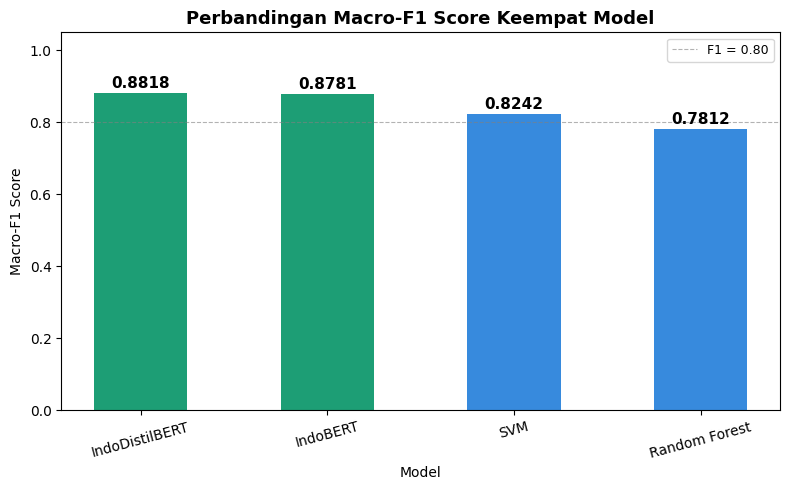

In [14]:
# VISUALISASI 1 — Bar Chart Macro-F1
family_color_map = {
    'Classical': '#378ADD',
    'Transformer': '#1D9E75'
}

colors_family = (
    summary_eval_df['family']
    .map(family_color_map)
    .tolist()
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(summary_eval_df['model'], summary_eval_df['f1_macro'],
              color=colors_family, width=0.5)
for bar, val in zip(bars, summary_eval_df['f1_macro']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Perbandingan Macro-F1 Score Keempat Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Macro-F1 Score')
ax.set_xlabel('Model')
ax.set_ylim(0, 1.05)
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='F1 = 0.80')
ax.legend(fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f'{FINAL_ARTIFACT_DIR}/bar_macro_f1.png', bbox_inches='tight', dpi=150)
plt.show()

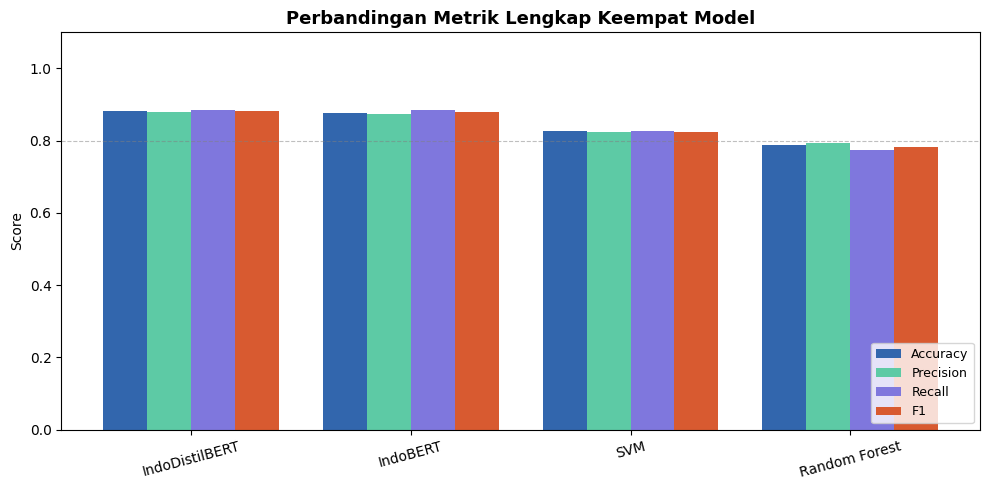

In [15]:
# VISUALISASI 2 — Grouped Bar: Accuracy, Precision, Recall, F1
metrics_to_plot = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
x     = np.arange(len(summary_eval_df))
width = 0.2
bar_colors = ['#3266ad', '#5DCAA5', '#7F77DD', '#D85A30']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (metric, color) in enumerate(zip(metrics_to_plot, bar_colors)):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, summary_eval_df[metric], width,
                  label=metric.replace('_macro','').capitalize(), color=color)

ax.set_title('Perbandingan Metrik Lengkap Keempat Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(summary_eval_df['model'], rotation=15)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right', fontsize=9)
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig(f'{FINAL_ARTIFACT_DIR}/bar_all_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

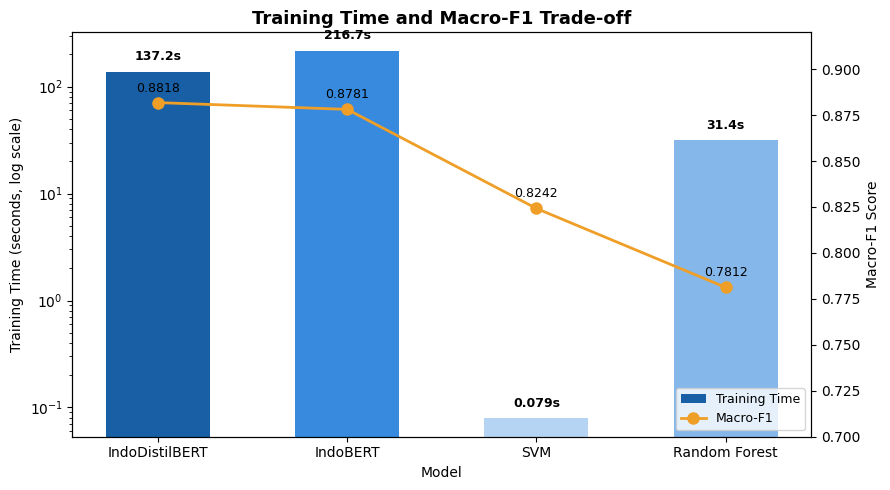

In [16]:
# VISUALISASI 3 — Training Time vs Macro-F1
fig, ax1 = plt.subplots(figsize=(9, 5))

model_time_colors = {
    'SVM': '#B5D4F4',
    'Random Forest': '#85B7EB',
    'IndoBERT': '#378ADD',
    'IndoDistilBERT': '#185FA5'
}

training_colors = (
    summary_eval_df['model']
    .map(model_time_colors)
    .tolist()
)

bars = ax1.bar(
    summary_eval_df['model'],
    summary_eval_df['train_time_sec'],
    color=training_colors,
    width=0.55,
    label='Training Time'
)

ax1.set_yscale('log')

ax1.set_ylabel('Training Time (seconds, log scale)')
ax1.set_xlabel('Model')

for bar, val in zip(
    bars,
    summary_eval_df['train_time_sec']
):
    if pd.isna(val):
        continue

    if val < 1:
        time_label = f'{val:.3f}s'
    elif val < 10:
        time_label = f'{val:.2f}s'
    else:
        time_label = f'{val:.1f}s'

    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.20,
        time_label,
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax2 = ax1.twinx()

ax2.plot(
    summary_eval_df['model'],
    summary_eval_df['f1_macro'],
    color='#EF9F27',
    marker='o',
    linewidth=2,
    markersize=8,
    label='Macro-F1'
)

ax2.set_ylabel('Macro-F1 Score')
ax2.set_ylim(0.70, 0.92)

for model_name, f1_value in zip(
    summary_eval_df['model'],
    summary_eval_df['f1_macro']
):
    ax2.annotate(
        f'{f1_value:.4f}',
        xy=(model_name, f1_value),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=9
    )

ax1.set_title(
    'Training Time and Macro-F1 Trade-off',
    fontsize=13,
    fontweight='bold'
)

plt.xticks(rotation=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='lower right',
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    f'{FINAL_ARTIFACT_DIR}/efficiency_tradeoff.png',
    bbox_inches='tight',
    dpi=300
)

plt.show()

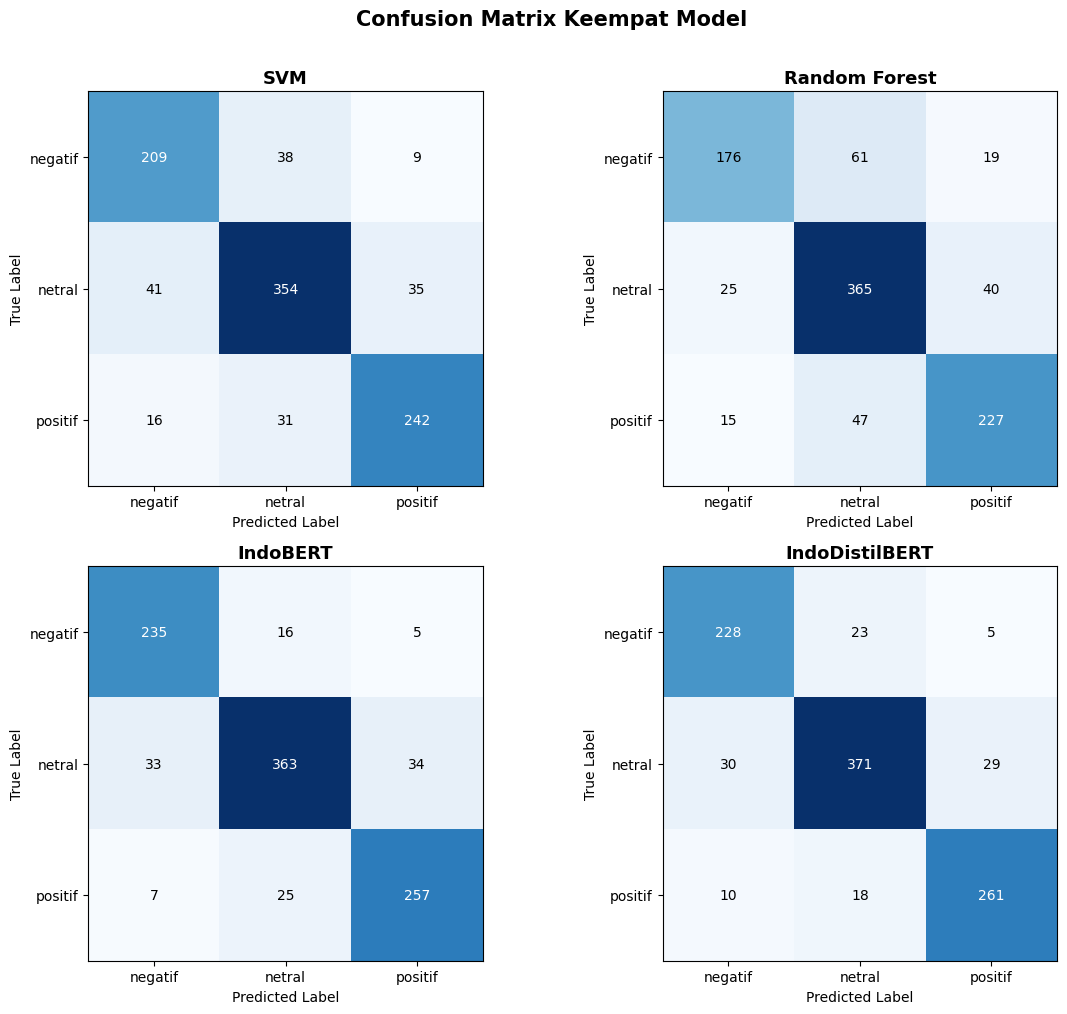

Semua confusion matrix berhasil disimpan.


In [17]:
# VISUALISASI 4 — Confusion Matrix 2x2
svm_cm            = confusion_matrix(y_test, svm_pred)
rf_cm             = confusion_matrix(y_test, rf_pred)
indobert_cm       = confusion_matrix(y_test, indobert_pred)
indodistilbert_cm = confusion_matrix(y_test, indodistilbert_pred)  # ← GANTI

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrix Keempat Model', fontsize=15, fontweight='bold', y=1.01)

plot_confusion_matrix(axes[0, 0], svm_cm,            label_names, 'SVM')
plot_confusion_matrix(axes[0, 1], rf_cm,             label_names, 'Random Forest')
plot_confusion_matrix(axes[1, 0], indobert_cm,       label_names, 'IndoBERT')
plot_confusion_matrix(axes[1, 1], indodistilbert_cm, label_names, 'IndoDistilBERT')  # ← GANTI

plt.tight_layout()
plt.savefig(f'{FINAL_ARTIFACT_DIR}/confusion_matrix_all_models.png', bbox_inches='tight', dpi=150)
plt.show()

for name, cm in [('svm', svm_cm), ('rf', rf_cm),
                 ('indobert', indobert_cm), ('indodistilbert', indodistilbert_cm)]:
    fig, ax = plt.subplots(figsize=(6, 5))
    plot_confusion_matrix(ax, cm, label_names, f'Confusion Matrix - {name.upper()}')
    plt.tight_layout()
    plt.savefig(f'{FINAL_ARTIFACT_DIR}/confusion_matrix_{name}.png', bbox_inches='tight', dpi=150)
    plt.close()

print("Semua confusion matrix berhasil disimpan.")

In [18]:
best_model_row  = summary_eval_df.iloc[0]
worst_model_row = summary_eval_df.iloc[-1]

print("\nMODEL TERBAIK:")
display(best_model_row.to_frame().T)

print("\nMODEL TERBURUK:")
display(worst_model_row.to_frame().T)

best_model_name = best_model_row['model']
pred_map = {
    'IndoBERT'      : indobert_pred_df,
    'IndoDistilBERT': indodistilbert_pred_df,  # ← GANTI
    'SVM'           : svm_pred_df if 'svm_pred_df' in dir() else None,
    'Random Forest' : rf_pred_df  if 'rf_pred_df'  in dir() else None,
}
best_pred_df = pred_map.get(best_model_name)

if best_pred_df is not None:
    print(f"\nContoh prediksi BENAR dari {best_model_name}:")
    display(best_pred_df[best_pred_df['is_correct'] == True].sample(5, random_state=42))
    print(f"\nContoh prediksi SALAH dari {best_model_name}:")
    display(best_pred_df[best_pred_df['is_correct'] == False].sample(5, random_state=42))

print(f"\nModel terbaik: {best_model_row['model']} | Macro-F1 = {best_model_row['f1_macro']:.4f}")
print(f"Model terburuk: {worst_model_row['model']} | Macro-F1 = {worst_model_row['f1_macro']:.4f}")

print("\nIsi folder final evaluation:")
print(os.listdir(FINAL_ARTIFACT_DIR))


MODEL TERBAIK:


,model,family,accuracy,precision_macro,recall_macro,f1_macro,train_time_sec
0,IndoDistilBERT,Transformer,0.882051,0.878659,0.88551,0.881767,137.237691



MODEL TERBURUK:


,model,family,accuracy,precision_macro,recall_macro,f1_macro,train_time_sec
3,Random Forest,Classical,0.787692,0.793397,0.773935,0.781248,31.376426



Contoh prediksi BENAR dari IndoDistilBERT:


,judul,text_clean,sentimen,label_id,pred_label_id,pred_sentimen,is_correct
813,Kiat Investasi Jangka Panjang Ala Warren Buffe...,kiat investasi jangka panjang ala warren buffe...,netral,1,1,netral,True
684,Rupiah Menguat Usai Tiga Hari Beruntun Terteka...,rupiah menguat usai tiga hari beruntun terteka...,positif,2,2,positif,True
137,"J Trust Bank Siap Pacu Kredit Ritel, Ini Alasa...","j trust bank siap pacu kredit ritel, ini alasa...",positif,2,2,positif,True
236,"OJK Terbitkan Aturan Suku Bunga Bank, Ini 11 P...","ojk terbitkan aturan suku bunga bank, ini 11 p...",netral,1,1,netral,True
427,Warren Buffett Beri Nasihat Keuangan Untuk Par...,warren buffett beri nasihat keuangan untuk par...,netral,1,1,netral,True



Contoh prediksi SALAH dari IndoDistilBERT:


,judul,text_clean,sentimen,label_id,pred_label_id,pred_sentimen,is_correct
694,Sektor Usaha Ini Bakal Dapat Subsidi Kredit 5%...,sektor usaha ini bakal dapat subsidi kredit 5 ...,netral,1,2,positif,False
39,Emiten Media Bakrie (VIVA) Restruktuturisasi U...,emiten media bakrie (viva) restruktuturisasi u...,positif,2,0,negatif,False
344,Pengadilan Cabut Permohonan PKPU Atas Waskita ...,pengadilan cabut permohonan pkpu atas waskita ...,netral,1,0,negatif,False
590,Harga Minyak Terkoreksi Tipis Usai The Fed Ung...,harga minyak terkoreksi tipis usai the fed ung...,positif,2,0,negatif,False
96,"Sedang Rapat di Komisi VI, Erick Thohir Mendad...","sedang rapat di komisi vi, erick thohir mendad...",negatif,0,1,netral,False



Model terbaik: IndoDistilBERT | Macro-F1 = 0.8818
Model terburuk: Random Forest | Macro-F1 = 0.7812

Isi folder final evaluation:
['bar_accuracy.png', 'bar_train_time.png', 'confusion_matrix_indobert_lite.png', 'final_model_comparison.csv', 'bar_macro_f1.png', 'bar_all_metrics.png', 'efficiency_tradeoff.png', 'confusion_matrix_all_models.png', 'confusion_matrix_rf.png', 'confusion_matrix_svm.png', 'confusion_matrix_indobert.png', 'confusion_matrix_indodistilbert.png']
